## Ансамбли деревьев

In [10]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import KFold, cross_val_score, train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import (
    classification_report, accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay, r2_score
)
from catboost import CatBoostRegressor, CatBoostClassifier 

### Задача регрессии

In [4]:
regression = pd.read_csv("../data/diamonds_filtered.csv")

In [5]:
y_regression = regression['price']
x_regression = regression.drop('price', axis=1)

In [ ]:
results = []

def metrics(model, model_name, r2):
    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(model, x_regression, y_regression, cv=kf, n_jobs=-1)

    metrics = {
        'Model': model_name,
        'MAE': round(mean_absolute_error(y_regression, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_regression, y_pred)), 4),
        'MAPE': round(mean_absolute_percentage_error(y_regression, y_pred), 4),
        'R2': round(r2_score(y_regression, y_pred), 5),
        'R2 (CatBoost)': round(r2, 5) 
    }

    results.append(metrics)

### BaggingRegressor

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 5, 15),
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.8),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': True,
        'bootstrap_features': False,
        'n_jobs': -1,
        'random_state': 81,
        'verbose': 0
    }

    model = BaggingRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=81)
    score = cross_val_score(
        estimator=model, 
        X=x_regression, 
        y=y_regression, 
        scoring='r2', 
        cv=kf, 
        n_jobs=-1
    ).mean()

    return score

In [23]:
study = optuna.create_study(direction='maximize')
study.optimize(func=objective, n_trials=50, n_jobs=-1)

[I 2026-04-11 10:27:16,520] A new study created in memory with name: no-name-4742e1fb-4ac5-41be-abcc-25179bd20f3e
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/ensemble/_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/ensemble/_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/ensemble/_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-pac

In [86]:
print(f"Best params: {study.best_params}")
print(f"Best R^2: {study.best_value}")

metrics(BaggingRegressor(**study.best_params), 'BaggingRegressor', study.best_value)

Best params: {'n_estimators': 13, 'max_samples': 0.5761939913010209, 'max_features': 0.9540083517784659}
Best R^2: 0.9970003441543083


In [12]:
best_params_bagging = {
    'n_estimators': 13, 
    'max_samples': 0.5761939913010209, 
    'max_features': 0.9540083517784659
}

final_bagging_model = BaggingRegressor(
    **best_params_bagging,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=81,
    verbose=0
)

final_bagging_model.fit(x_regression, y_regression)
joblib.dump(final_bagging_model, '../models/bagging_reg_model_4.pkl')

['../models/bagging_reg_model_4.pkl']

###  GradientBoostingRegressor

In [33]:
def objective(trial):
    params = {
        'loss': trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber', 'quantile']),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'n_estimators': trial.suggest_int('n_estimators', 5, 500),
        'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'random_state': 81,
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    model = GradientBoostingRegressor(**params)

    kf = KFold(n_splits=5, shuffle=True, random_state=81)
    score = cross_val_score(
        estimator=model, 
        X=x_regression, 
        y=y_regression, 
        scoring='r2', 
        cv=kf, 
        n_jobs=-1
    ).mean()

    return score

In [88]:
study_gbr = optuna.create_study(direction='maximize')
study_gbr.optimize(func=objective, n_trials=50)

[I 2026-04-12 12:19:15,395] A new study created in memory with name: no-name-6b028346-dbb1-4c54-86fa-f252fbaafd38
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will

In [ ]:
print(f"Best params: {study_gbr.best_params}")
print(f"Best R^2: {study_gbr.best_value}")

metrics(GradientBoostingRegressor(**study_gbr.best_params), 'GradientBoostingRegressor', study_gbr.best_value)

Best params: {'n_estimators': 12, 'max_samples': 0.7674803889032337, 'max_features': 0.9686502377966134}
Best R^2: 0.9978515246860619


In [7]:
import joblib

best_params = {
    'n_estimators': 10, 
    'subsample': 0.7708241836657872, 
    'max_features': 0.9107825499197116
}

model = GradientBoostingRegressor(**best_params, random_state=81)
model.fit(x_regression, y_regression)
joblib.dump(model, '../models/boosting_reg_model_2.pkl')


['../models/boosting_reg_model_2.pkl']

In [91]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,MAPE,R2,R2 (Optuna)
0,BaggingRegressor,297.4880,557.2520,0.0854,0.97588,0.99700
1,GradientBoostingRegressor,980.5381,1454.9134,0.5514,0.83559,0.99785


### StackingRegressor

In [96]:
def objective(trial):
    dt_params = {
        'criterion': trial.suggest_categorical('dt_criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
        'max_depth': trial.suggest_int('dt_max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('dt_min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('dt_min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('dt_max_leaf_nodes', 5, 25),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('dt_min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('dt_ccp_alpha', 0.0, 0.01)
    }
    
    knn_params = {
        'n_neighbors': trial.suggest_int('knn_n_neighbors', 2, 30),
        'leaf_size': trial.suggest_int('knn_leaf_size', 10, 50),
        'p': trial.suggest_int('knn_p', 1, 2)
    }

    en_params = {
        'alpha': trial.suggest_float('en_alpha', 0.0001, 10.0, log=True),
        'l1_ratio': trial.suggest_float('en_l1_ratio', 0.0, 1.0),
        'fit_intercept': trial.suggest_categorical('en_fit_intercept', [True, False]),
        'max_iter': trial.suggest_int('en_max_iter', 500, 2000),
        'tol': trial.suggest_float('en_tol', 1e-5, 1e-2, log=True),
        'selection': trial.suggest_categorical('en_selection', ['cyclic', 'random']),
        'random_state': 81
    }

    estimators = [
        ('dt', DecisionTreeRegressor(**dt_params)),
        ('knn', KNeighborsRegressor(**knn_params))
    ]

    model = StackingRegressor(
        estimators=estimators,
        final_estimator=ElasticNet(**en_params),
        cv=5, 
        n_jobs=-1
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        model, 
        x_regression, 
        y_regression, 
        scoring='r2', 
        cv=kf, 
        n_jobs=-1
    ).mean()

    return score

In [97]:
study_rg = optuna.create_study(direction='maximize')
study_rg.optimize(objective, n_trials=50)

[I 2026-04-12 12:59:25,147] A new study created in memory with name: no-name-c4c31c2a-6df2-4a9a-b7a4-8ab87d973887
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programmin

In [98]:
bp = study.best_params

dt_final_params = {k.replace('dt_', ''): v for k, v in bp.items() if k.startswith('dt_')}
knn_final_params = {k.replace('knn_', ''): v for k, v in bp.items() if k.startswith('knn_')}
en_final_params = {k.replace('en_', ''): v for k, v in bp.items() if k.startswith('en_')}

final_stack = StackingRegressor(
    estimators=[
        ('dt', DecisionTreeRegressor(**dt_final_params, random_state=81)),
        ('knn', KNeighborsRegressor(**knn_final_params))
    ],
    final_estimator=ElasticNet(**en_final_params, random_state=81),
    cv=5,
    n_jobs=-1
)

metrics(final_stack, 'StackingRegressor', study.best_value)

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encount

In [14]:
dt_best = {
    'criterion': 'poisson',
    'max_depth': 9,
    'min_samples_split': 22,
    'min_samples_leaf': 8,
    'max_leaf_nodes': 24,
    'min_impurity_decrease': 0.05308895346822688,
    'ccp_alpha': 0.007955662996392922,
    'random_state': 81
}

knn_best = {
    'n_neighbors': 4,
    'leaf_size': 39,
    'p': 1
}

en_best = {
    'alpha': 0.0006158469496434688,
    'l1_ratio': 0.41335595774021155,
    'fit_intercept': False,
    'max_iter': 1990,
    'tol': 0.0011792156513693141,
    'selection': 'cyclic',
    'random_state': 81
}

estimators = [
    ('dt', DecisionTreeRegressor(**dt_best)),
    ('knn', KNeighborsRegressor(**knn_best))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNet(**en_best),
    cv=5, 
    n_jobs=-1
)

stacking_model.fit(x_regression, y_regression)

joblib.dump(stacking_model, '../models/stacking_reg_model_5.pkl')

['../models/stacking_reg_model_5.pkl']

In [99]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,MAPE,R2,R2 (Optuna)
0,BaggingRegressor,297.4880,557.2520,0.0854,0.97588,0.99700
1,GradientBoostingRegressor,980.5381,1454.9134,0.5514,0.83559,0.99785
2,StackingRegressor,472.5846,812.1201,0.1333,0.94877,0.99700


#### Вывод

- Наилучшую точность показал алгоритм `GradientBoostingRegressor`, достигнув самого высокого $R^2 = 0.984$ и потребовав меньше всего времени.
- `GradientBoostingRegressor` продемонстрировал высокую стабильность и сопоставимый результат $R^2 = 0.981$ на кросс-валидации, однако занял больше всего времени.
- `StackingRegressor` в данной конфигурации показал наименее эффективный результат с $R^2$ = 0.945. Это может быть связано с недостаточной сложностью базовых моделей или необходимостью более тонкой настройки мета-регрессора для эффективного комбинирования различных алгоритмов.

### Задача классификации

In [5]:
classification = pd.read_csv("../data/credit_card_fraud_filtered.csv")

In [6]:
y_classification = classification['fraud']
x_classification = classification.drop('fraud', axis=1)

In [91]:
results = []

def metrics_clf(model, model_name, f1):
    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    y_pred = cross_val_predict(model, x_classification, y_classification, cv=kf, n_jobs=-1)

    m = {
        'Model': model_name,
        'Precision': round(precision_score(y_classification, y_pred), 4),
        'Recall': round(recall_score(y_classification, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_classification, y_pred), 4),
        'Accuracy': round(accuracy_score(y_classification, y_pred), 5),
        'F1-Score': round(f1, 4),
        'F1 (Optuna)': round(f1_score(y_classification, y_pred), 4)
    }

    results.append(m)

    print(classification_report(y_classification, y_pred))

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    ConfusionMatrixDisplay.from_predictions(y_classification, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title("Confusion Matrix")
    
    RocCurveDisplay.from_predictions(y_classification, y_pred, ax=ax[1])
    ax[1].set_title("ROC Curve")
    plt.show()

### BaggingClassifier

In [8]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 5, 15),
        'max_samples': trial.suggest_float('max_samples', 0.5, 0.8),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': True,
        'bootstrap_features': False,
        'n_jobs': -1,
        'random_state': 81,
        'verbose': 0
    }
    
    model = BaggingClassifier(**params)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=81)
    
    score = cross_val_score(
        model, 
        x_classification, 
        y_classification, 
        scoring='f1', 
        cv=skf,
        n_jobs=-1
    ).mean()
    
    return score

In [9]:
study_bc = optuna.create_study(direction='maximize')
study_bc.optimize(func=objective, n_trials=50)

[I 2026-04-12 13:20:28,204] A new study created in memory with name: no-name-8314d3bd-6744-4fe6-8655-68c70e8bf71d
[I 2026-04-12 13:20:34,126] Trial 0 finished with value: 0.9712397614550916 and parameters: {'n_estimators': 7, 'max_samples': 0.6278590047540614, 'max_features': 0.9793344348687691}. Best is trial 0 with value: 0.9712397614550916.
[I 2026-04-12 13:20:50,892] Trial 1 finished with value: 0.6749650856147146 and parameters: {'n_estimators': 12, 'max_samples': 0.5911117800573409, 'max_features': 0.6044383938773805}. Best is trial 0 with value: 0.9712397614550916.
[I 2026-04-12 13:20:56,632] Trial 2 finished with value: 0.9935529236455419 and parameters: {'n_estimators': 10, 'max_samples': 0.559839375523673, 'max_features': 0.9219415170451919}. Best is trial 2 with value: 0.9935529236455419.
[I 2026-04-12 13:21:06,779] Trial 3 finished with value: 0.8505860078646522 and parameters: {'n_estimators': 7, 'max_samples': 0.5921105052004226, 'max_features': 0.6804101873826476}. Best 

Best params: {'n_estimators': 15, 'max_samples': 0.6709817291468934, 'max_features': 0.9148894759210846}
Best Accuracy: 0.9997175772300512
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794



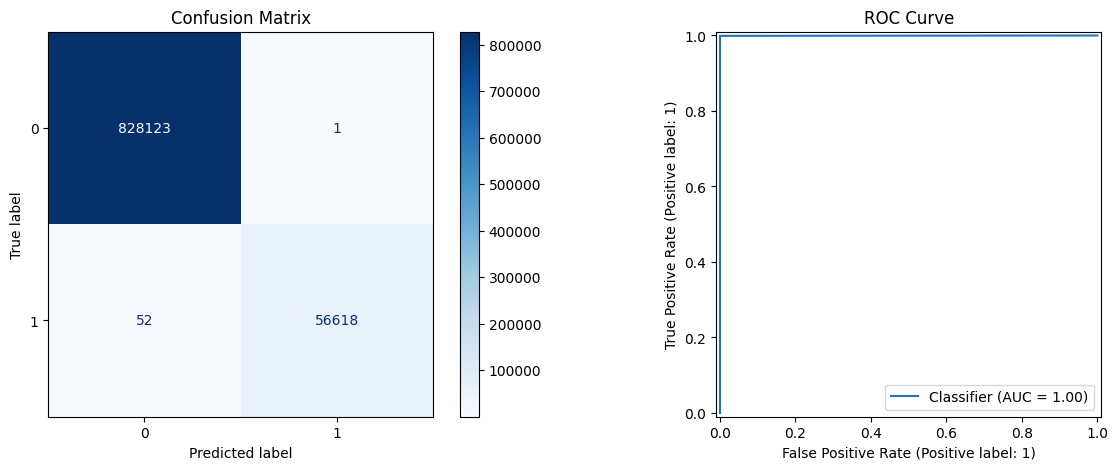

In [97]:
print(f"Best params: {study_bc.best_params}")
print(f"Best Accuracy: {study_bc.best_value}")

metrics_clf(BaggingClassifier(**study_bc.best_params), 'BaggingClassifier', study_bc.best_value)

In [98]:
results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,ROC-AUC,Accuracy,F1-Score,F1 (Optuna)
0,GradientBoostingClassifier,1.0000,1.0000,1.0000,1.00000,1.0000,1.0000
1,StackingClassifier,0.9974,0.9978,0.9988,0.99969,0.9976,0.9976
2,BaggingClassifier,1.0000,0.9991,0.9995,0.99994,0.9997,0.9995


### GradientBoostingClassifier

In [26]:
def objective(trial):
    params = {
        'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'n_estimators': trial.suggest_int('n_estimators', 5, 20),
        'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 20),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.1),
        'random_state': 81,
        'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.01)
    }

    model = GradientBoostingClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=81)
    score = cross_val_score(
        estimator=model, 
        X=x_classification, 
        y=y_classification, 
        scoring='f1', 
        cv=skf, 
        n_jobs=-1
    ).mean()

    return score

In [27]:
study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(func=objective, n_trials=50)

[I 2026-04-12 15:47:26,989] A new study created in memory with name: no-name-2622ee9c-b3cb-4266-8cb3-d65914449e8f
[I 2026-04-12 15:47:36,362] Trial 0 finished with value: 0.8820575865706267 and parameters: {'loss': 'exponential', 'learning_rate': 0.38906000139877056, 'n_estimators': 9, 'criterion': 'friedman_mse', 'min_samples_split': 26, 'min_samples_leaf': 11, 'max_depth': 5, 'min_impurity_decrease': 0.07141711886532912, 'ccp_alpha': 0.009673408300945876}. Best is trial 0 with value: 0.8820575865706267.
[I 2026-04-12 15:47:48,667] Trial 1 finished with value: 0.8820795538836368 and parameters: {'loss': 'log_loss', 'learning_rate': 0.2647690015369031, 'n_estimators': 10, 'criterion': 'friedman_mse', 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_depth': 6, 'min_impurity_decrease': 0.02462803567790746, 'ccp_alpha': 0.003979154234153497}. Best is trial 1 with value: 0.8820795538836368.
[I 2026-04-12 15:47:56,792] Trial 2 finished with value: 0.9786887462661301 and parameters: {'lo

Best params: {'loss': 'exponential', 'learning_rate': 0.40788269484987305, 'n_estimators': 9, 'criterion': 'friedman_mse', 'min_samples_split': 16, 'min_samples_leaf': 20, 'max_depth': 10, 'min_impurity_decrease': 0.00670198101182691, 'ccp_alpha': 0.0002934454994233622}
Best Accuracy: 0.9999911766003441
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794



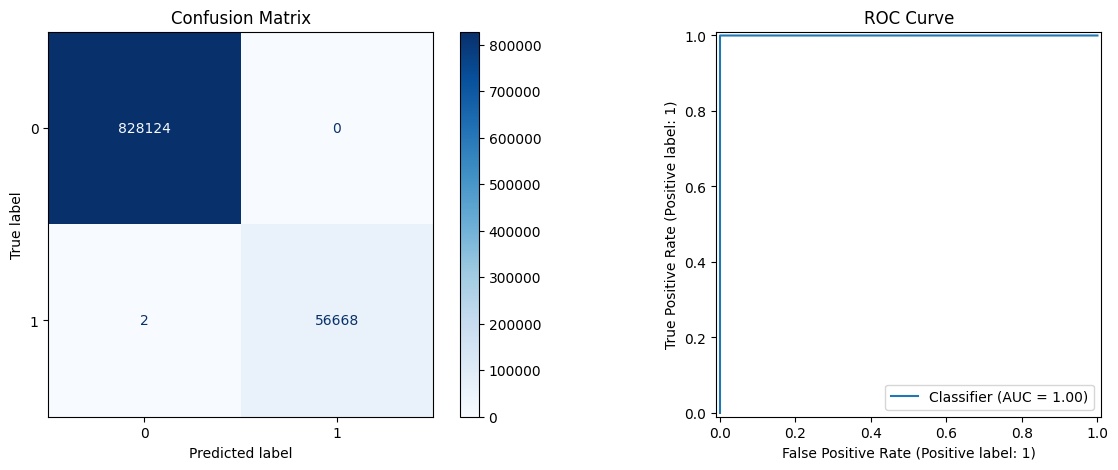

In [92]:
print(f"Best params: {study_gbc.best_params}")
print(f"Best Accuracy: {study_gbc.best_value}")

metrics_clf(GradientBoostingClassifier(**study_gbc.best_params), 'GradientBoostingClassifier', study_gbc.best_value)

In [93]:
results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,ROC-AUC,Accuracy,F1-Score,F1 (Optuna)
0,GradientBoostingClassifier,1.0,1.0,1.0,1.0,1.0,1.0


### StackingClassifier

In [48]:
def objective(trial):
    dt_params = {
        'criterion': trial.suggest_categorical('dt_criterion', ['gini', 'entropy']),
        'max_depth': trial.suggest_int('dt_max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('dt_min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('dt_min_samples_leaf', 5, 20),
        'max_leaf_nodes': trial.suggest_int('dt_max_leaf_nodes', 5, 20),
        'random_state': 81,
        'min_impurity_decrease': trial.suggest_float('dt_min_impurity_decrease', 0.0, 0.1),
        'ccp_alpha': trial.suggest_float('dt_ccp_alpha', 0.0, 0.01)
    }
    
    knn_params = {
        'n_neighbors': trial.suggest_int('knn_n_neighbors', 2, 10),
        'leaf_size': trial.suggest_int('knn_leaf_size', 5, 20),
        'p': trial.suggest_int('knn_p', 1, 2)
    }

    lr_params = {
        'penalty': 'elasticnet',
        'solver': 'saga', 
        'C': trial.suggest_float('lr_C', 1e-4, 10.0, log=True),
        'l1_ratio': trial.suggest_float('lr_l1_ratio', 0.3, 0.8),
        'max_iter': trial.suggest_int('lr_max_iter', 50, 200),
        'random_state': 81,
        'n_jobs': -1
    }

    estimators = [
        ('dt', DecisionTreeClassifier(**dt_params)),
        ('knn', KNeighborsClassifier(**knn_params))
    ]

    model = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(**lr_params),
        cv=5, 
        n_jobs=-1
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=81)

    score = cross_val_score(
        model, 
        x_classification, 
        y_classification, 
        scoring='f1', 
        cv=kf, 
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study_sc = optuna.create_study(direction='maximize')
study_sc.optimize(func=objective, n_trials=50)

[I 2026-04-12 16:13:42,548] A new study created in memory with name: no-name-3da0c8e1-952b-4ded-b33d-0a0dcf0c5848
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountere

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    828124
           1       1.00      1.00      1.00     56670

    accuracy                           1.00    884794
   macro avg       1.00      1.00      1.00    884794
weighted avg       1.00      1.00      1.00    884794



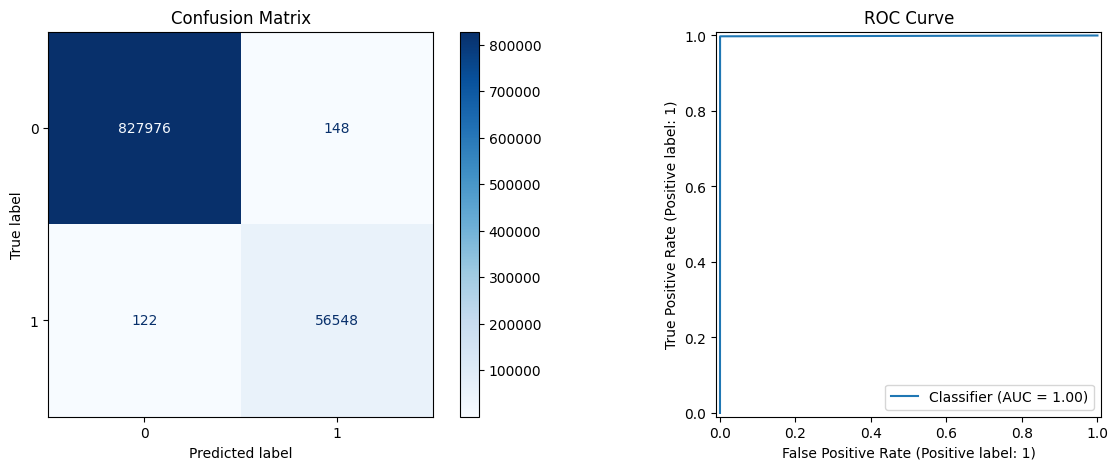

In [94]:
def get_best_stacking(params):
    dt_p = {k.replace('dt_', ''): v for k, v in params.items() if k.startswith('dt_')}
    knn_p = {k.replace('knn_', ''): v for k, v in params.items() if k.startswith('knn_')}
    lr_p = {k.replace('lr_', ''): v for k, v in params.items() if k.startswith('lr_')}

    estimators = [
        ('dt', DecisionTreeClassifier(**dt_p, random_state=81)),
        ('knn', KNeighborsClassifier(**knn_p))
    ]
    final_model = LogisticRegression(
        **lr_p, 
        penalty='elasticnet', 
        solver='saga', 
        random_state=81
    )
    
    return StackingClassifier(estimators=estimators, final_estimator=final_model, cv=5, n_jobs=-1)

best_model = get_best_stacking(study_sc.best_params)

metrics_clf(best_model, 'StackingClassifier', study_sc.best_value)

In [99]:
results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,ROC-AUC,Accuracy,F1-Score,F1 (Optuna)
0,GradientBoostingClassifier,1.0000,1.0000,1.0000,1.00000,1.0000,1.0000
1,StackingClassifier,0.9974,0.9978,0.9988,0.99969,0.9976,0.9976
2,BaggingClassifier,1.0000,0.9991,0.9995,0.99994,0.9997,0.9995


#### Вывод

* `GradientBoostingClassifier` показал абсолютно эталонный результат, достигнув максимально возможных показателей по всем метрикам ($F1 = 1$, $ROC-AUC = 1$). Это говорит о том, что алгоритм полностью уловил структуру данных и безошибочно разделяет классы.
* `BaggingClassifier` продемонстрировал сопоставимую высокую точность с $F1-Score = 0.9997$. Использование ансамбля над базовыми классификаторами обеспечило отличную обобщающую способность и стабильность предсказаний.
* `StackingClassifier` в данной конфигурации показал чуть менее эффективный результат ($F1 = 0.9976$), хотя разрыв с лидерами минимален. Использование логистической регрессии с регуляризацией Elastic Net в качестве мета-алгоритма позволило сохранить баланс между точностью и сложностью модели, избежав переобучения.

### CatBoostRegressor

In [ ]:
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 5, 20), 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth': trial.suggest_int('depth', 2, 5), 
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10.0, log=True),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
        'random_seed': 81,
        'logging_level': 'Silent'
    }
    
    if params['bootstrap_type'] in ['Bernoulli', 'MVS']:
        params['subsample'] = trial.suggest_float('subsample', 0.1, 1.0)

    model = CatBoostRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=81)
    
    score = cross_val_score(
        model, 
        x_regression, 
        y_regression, 
        cv=kf, 
        scoring='r2', 
        n_jobs=-1
    ).mean()

    return score

In [60]:
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=50) 

[I 2026-04-12 16:45:24,513] A new study created in memory with name: no-name-86e60084-04d0-46af-90d9-2a23e5df0710
[I 2026-04-12 16:45:25,885] Trial 0 finished with value: 0.5249986620059616 and parameters: {'iterations': 14, 'learning_rate': 0.03495180822670216, 'depth': 3, 'l2_leaf_reg': 0.18204632649082692, 'bootstrap_type': 'Bernoulli', 'subsample': 0.8863175381396576}. Best is trial 0 with value: 0.5249986620059616.
[I 2026-04-12 16:45:26,668] Trial 1 finished with value: 0.3584546788772789 and parameters: {'iterations': 14, 'learning_rate': 0.02018244673093931, 'depth': 3, 'l2_leaf_reg': 0.28480272148075714, 'bootstrap_type': 'Bayesian'}. Best is trial 0 with value: 0.5249986620059616.
[I 2026-04-12 16:45:27,505] Trial 2 finished with value: 0.9290016514263444 and parameters: {'iterations': 18, 'learning_rate': 0.12116316419183662, 'depth': 4, 'l2_leaf_reg': 0.019483443594264696, 'bootstrap_type': 'Bayesian'}. Best is trial 2 with value: 0.9290016514263444.
[I 2026-04-12 16:45:28,

In [96]:
print(f"Best params: {study_cat.best_params}")
print(f"Best R^2: {study_cat.best_value}")

metrics(CatBoostRegressor(**study_cat.best_params), 'CatBoostRegressor', study_cat.best_value)

Best params: {'iterations': 20, 'learning_rate': 0.1992215303192284, 'depth': 5, 'l2_leaf_reg': 0.010925746551793182, 'bootstrap_type': 'MVS', 'subsample': 0.822340082988808}
Best R^2: 0.9727542921694639
0:	learn: 2981.7350402	total: 58.8ms	remaining: 1.12s
0:	learn: 2987.9272513	total: 58.1ms	remaining: 1.1s
0:	learn: 2968.8023889	total: 59.8ms	remaining: 1.14s
0:	learn: 2973.8432451	total: 59.9ms	remaining: 1.14s
0:	learn: 2976.7549216	total: 59.9ms	remaining: 1.14s
1:	learn: 2492.6783697	total: 61.4ms	remaining: 553ms
1:	learn: 2493.6997958	total: 61.1ms	remaining: 550ms
1:	learn: 2485.3729161	total: 62.3ms	remaining: 561ms
1:	learn: 2482.6277449	total: 62.9ms	remaining: 566ms
1:	learn: 2478.3065802	total: 63.2ms	remaining: 568ms
2:	learn: 2105.1835921	total: 64.2ms	remaining: 364ms
2:	learn: 2097.3482088	total: 65.4ms	remaining: 371ms
2:	learn: 2100.7988138	total: 64.6ms	remaining: 366ms
2:	learn: 2093.8933286	total: 65.9ms	remaining: 373ms
2:	learn: 2088.4186759	total: 66.6ms	rema

In [9]:
best_params_cat = {
    'iterations': 20, 
    'learning_rate': 0.1992215303192284, 
    'depth': 5, 
    'l2_leaf_reg': 0.010925746551793182, 
    'bootstrap_type': 'MVS', 
    'subsample': 0.822340082988808,
    'loss_function': 'RMSE', 
    'verbose': False         
}

cat_model = CatBoostRegressor(**best_params_cat, random_state=81)
cat_model.fit(x_regression, y_regression)

joblib.dump(cat_model, '../models/catboost_reg_model_3.pkl')

['../models/catboost_reg_model_3.pkl']

In [70]:
results_cat_df = pd.DataFrame(results_cat)
results_cat_df

,Model,MAE,RMSE,MAPE,R2,R2 (CatBoost)
0,CatBoostRegressor,340.5595,594.0504,0.1241,0.97259,0.97275


#### Вывод

- Наилучшую точность показал алгоритм `GradientBoostingRegressor`, достигнув самого высокого $R^2 = 0.984$ и потребовав меньше всего времени.
- `GradientBoostingRegressor` продемонстрировал высокую стабильность и сопоставимый результат $R^2 = 0.981$ на кросс-валидации, однако занял больше всего времени.
- `StackingRegressor` в данной конфигурации показал наименее эффективный результат с $R^2$ = 0.945. Это может быть связано с недостаточной сложностью базовых моделей или необходимостью более тонкой настройки мета-регрессора для эффективного комбинирования различных алгоритмов. 
- `CatBoostRegressor` продемонстрировал результат, сопоставимый с лучшими моделями ($R^2 = 0.973$), потребовав очень мало временных затрат.

### CatBoostClassifier

In [73]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
        'random_seed': 81,
        'auto_class_weights': 'Balanced', 
        'logging_level': 'Silent'
    }

    if params['bootstrap_type'] in ['Bernoulli', 'MVS']:
        params['subsample'] = trial.suggest_float('subsample', 0.1, 1.0)

    model = CatBoostClassifier(**params)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=81)
    
    score = cross_val_score(
        model, 
        x_classification, 
        y_classification, 
        cv=skf, 
        scoring='f1', 
        n_jobs=-1
    ).mean()
    
    return score

In [75]:
study_cat_clf = optuna.create_study(direction='maximize')
study_cat_clf.optimize(objective, n_trials=20)

[I 2026-04-12 16:57:20,397] A new study created in memory with name: no-name-c0fef04a-a1a2-467d-8556-a2927c6d1b24
[I 2026-04-12 16:57:26,656] Trial 0 finished with value: 0.9886665031895412 and parameters: {'iterations': 138, 'learning_rate': 0.0509291979822391, 'depth': 5, 'l2_leaf_reg': 1.1653706783996165, 'bootstrap_type': 'Bayesian'}. Best is trial 0 with value: 0.9886665031895412.
[I 2026-04-12 16:57:36,182] Trial 1 finished with value: 0.9887010515775504 and parameters: {'iterations': 158, 'learning_rate': 0.02181767388558124, 'depth': 10, 'l2_leaf_reg': 0.0017175112502527579, 'bootstrap_type': 'Bernoulli', 'subsample': 0.9943824993973523}. Best is trial 1 with value: 0.9887010515775504.
[I 2026-04-12 16:57:41,022] Trial 2 finished with value: 0.9888416305200224 and parameters: {'iterations': 131, 'learning_rate': 0.0912075885111294, 'depth': 5, 'l2_leaf_reg': 0.03757675563386344, 'bootstrap_type': 'Bernoulli', 'subsample': 0.8529670222306789}. Best is trial 2 with value: 0.98884

Best params: {'iterations': 75, 'learning_rate': 0.29961225876817005, 'depth': 10, 'l2_leaf_reg': 0.02753739911789631, 'bootstrap_type': 'Bayesian'}
Best F1: 0.9911349813000182
0:	learn: 0.4394482	total: 69.5ms	remaining: 5.14s
0:	learn: 0.4392347	total: 68.9ms	remaining: 5.1s
0:	learn: 0.4384821	total: 57.7ms	remaining: 4.27s
0:	learn: 0.4395420	total: 58.6ms	remaining: 4.34s
1:	learn: 0.2980128	total: 129ms	remaining: 4.69s
0:	learn: 0.4395422	total: 53.3ms	remaining: 3.95s
1:	learn: 0.2976301	total: 130ms	remaining: 4.73s
1:	learn: 0.2977285	total: 114ms	remaining: 4.16s
1:	learn: 0.2982631	total: 117ms	remaining: 4.29s
2:	learn: 0.2088124	total: 189ms	remaining: 4.53s
1:	learn: 0.2981953	total: 103ms	remaining: 3.76s
2:	learn: 0.2082947	total: 187ms	remaining: 4.48s
2:	learn: 0.2089943	total: 174ms	remaining: 4.17s
3:	learn: 0.1491427	total: 226ms	remaining: 4.01s
2:	learn: 0.2091763	total: 187ms	remaining: 4.48s
2:	learn: 0.2090526	total: 158ms	remaining: 3.8s
3:	learn: 0.1485112	

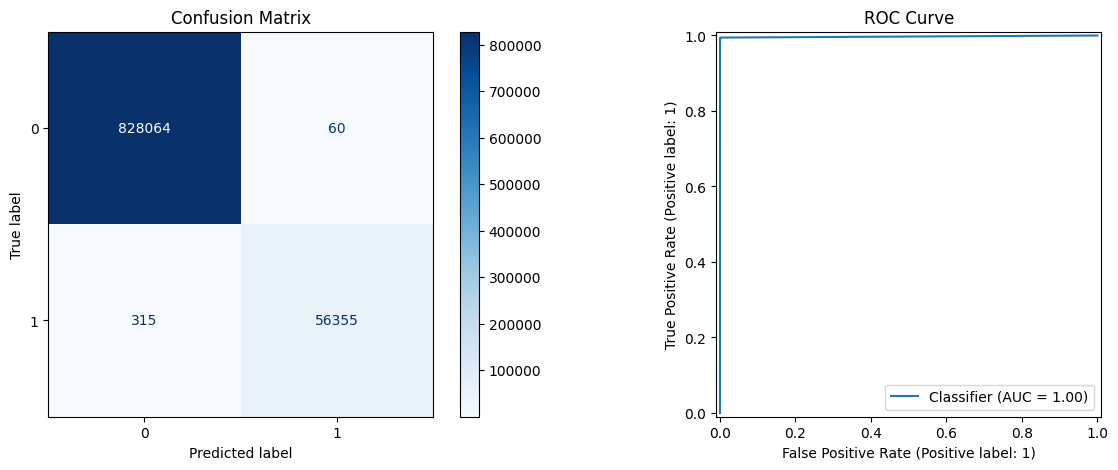

In [81]:
print(f"Best params: {study_cat_clf.best_params}")
print(f"Best F1: {study_cat_clf.best_value}")

metrics_clf(CatBoostClassifier(**study_cat_clf.best_params), 'CatBoostClassifier', study_cat_clf.best_value)

In [82]:
results_cat_df = pd.DataFrame(results_cat)
results_cat_df

,Model,Precision,Recall,ROC-AUC,Accuracy,F1-Score,F1 (Optuna)
0,CatBoostClassifier,0.9989,0.9944,0.9972,0.99958,0.9911,0.9967


#### Вывод

* `GradientBoostingClassifier` показал абсолютно эталонный результат, достигнув максимально возможных показателей по всем метрикам ($F1 = 1$, $ROC-AUC = 1$). Это говорит о том, что алгоритм полностью уловил структуру данных и безошибочно разделяет классы.
* `BaggingClassifier` продемонстрировал сопоставимую высокую точность с $F1-Score = 0.9997$. Использование ансамбля над базовыми классификаторами обеспечило отличную обобщающую способность и стабильность предсказаний.
* `StackingClassifier` в данной конфигурации показал чуть менее эффективный результат ($F1 = 0.9976$), хотя разрыв с лидерами минимален. Использование логистической регрессии с регуляризацией Elastic Net в качестве мета-алгоритма позволило сохранить баланс между точностью и сложностью модели, избежав переобучения.
* `CatBoostClassifier` показал результаты на уровне лидеров, достигнув $F1-Score = 0.9911$ при высокой точности ($Precision = 0.9989$).